In [1]:
import sys
import os
from pathlib import Path

sys.path.append(str(Path.cwd().parents[0]))

%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf

devices = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(devices))
print(devices)

for device in devices:
    tf.config.experimental.set_memory_growth(device,True)



Num GPUs Available: 0
[]


In [3]:
import pandas as pd
import numpy as np
import keras

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline

from dataset.dataset import create_dataset, createOutputLabels
from alz_prog_net.model import AlzProgNet

In [4]:
X, y, groups = create_dataset()

In [5]:
target_tensors = createOutputLabels(y)
y_stable = y["stable"].to_numpy()

In [6]:
# -------------------------
# 80% train / 20% temp
# -------------------------
sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, temp_idx = next(
    sgkf.split(X, y_stable, groups)
)

X_train = X.iloc[train_idx]
y_train = target_tensors[train_idx]

X_temp = X.iloc[temp_idx]
y_stable_temp = y_stable[temp_idx]
target_tensors_temp = target_tensors[temp_idx]
groups_temp = groups[temp_idx]


# -------------------------
# 10% validation / 10% test
# -------------------------
sgkf2 = StratifiedGroupKFold(
    n_splits=2,
    shuffle=True,
    random_state=42
)

val_idx, test_idx = next(
    sgkf2.split(X_temp, y_stable_temp, groups_temp)
)

X_val = X_temp.iloc[val_idx]
y_val = target_tensors_temp[val_idx]

X_test = X_temp.iloc[test_idx]
y_test = target_tensors_temp[test_idx]


In [7]:
X_test.shape, X_val.shape, X_test.shape

((561, 26), (556, 26), (561, 26))

In [8]:
# model = AlzProgNet(
#     num_modalities=5,
#     modalities_hidden_dims=[16, 128],
#     modality_output_dim=64,
#     latent_dim=256,
#     num_transformer_layers=3,
#     num_heads=2,
#     ff_dim=128,
#     dropout=0.1,
#     progression_hidden_dims=(128, 64, 32),
#     time_points=(0, 6, 12, 24),
#     temporal_levels=(True, True, False),
#     time_dim=16,
#     n_time_frequencies=4,
#     use_time=True,
#     use_gate=True,
#     use_residual=True,
#     initial_residual_scale=0.1,
#     output_dim=3
# )

model = AlzProgNet(
    num_modalities=5,
    modalities_hidden_dims=[32, 512],
    modality_output_dim=128,
    latent_dim=512,
    num_transformer_layers=3,
    num_heads=2,
    ff_dim=512,
    dropout=0.1,
    progression_hidden_dims=(128, 32, 16),
    time_points=(0, 6, 12, 24),
    temporal_levels=(True, True, True),
    time_dim=16,
    n_time_frequencies=4,
    use_time=True,
    use_gate=True,
    use_residual=True,
    initial_residual_scale=0.1,
    output_dim=3
)

modality_dims = [6, 2, 11, 3, 4]
inputs = [
    keras.Input(
        shape=(dim,),
        name=f"modality_{i}"
    ) for i, dim in enumerate(modality_dims)
]

outputs = model(inputs)

alz_prog_net = keras.Model(inputs=inputs, outputs=outputs, name="AlzProgNet")




In [9]:
alz_prog_net.summary(expand_nested=True)

Model: "AlzProgNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ modality_0          │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modality_1          │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modality_2          │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modality_3          │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ modality_4          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ alz_prog_net        │ (None, 4, 3)      │  2,187,158 │ modality_0[0][0], │
│ (AlzProgNet)        │                   │            │ modality_1[0][0], │
│                     │                   │            │ modality_2[0][0], │
│                     │                   │            │ modality_3[0][0], │
│                     │                   │            │ modality_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ ?                 │     82,784 │ -                 │
│ modality_encoder    │                   │            │                   │
│ (ModalityEncoder)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ (None, 32)        │        224 │ -                 │
│ modality_encoder_0… │                   │            │                   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ ?                 │          0 │ -                 │
│ modality_encoder_0… │                   │            │                   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ (None, 512)       │     16,896 │ -                 │
│ modality_encoder_0… │                   │            │                   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ (None, 128)       │     65,664 │ -                 │
│ modality_encoder_0… │                   │            │                   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│       └             │ ?                 │          0 │ -                 │
│ modality_encoder_0… │                   │            │                   │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│    └                │ ?                 │     82,656 │ -                 │
│ modality_encoder_1  │                   │            │                   │
│ (ModalityEncoder)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 2,187,158 (8.34 MB)

 Trainable params: 2,187,158 (8.34 MB)

 Non-trainable params: 0 (0.00 B)

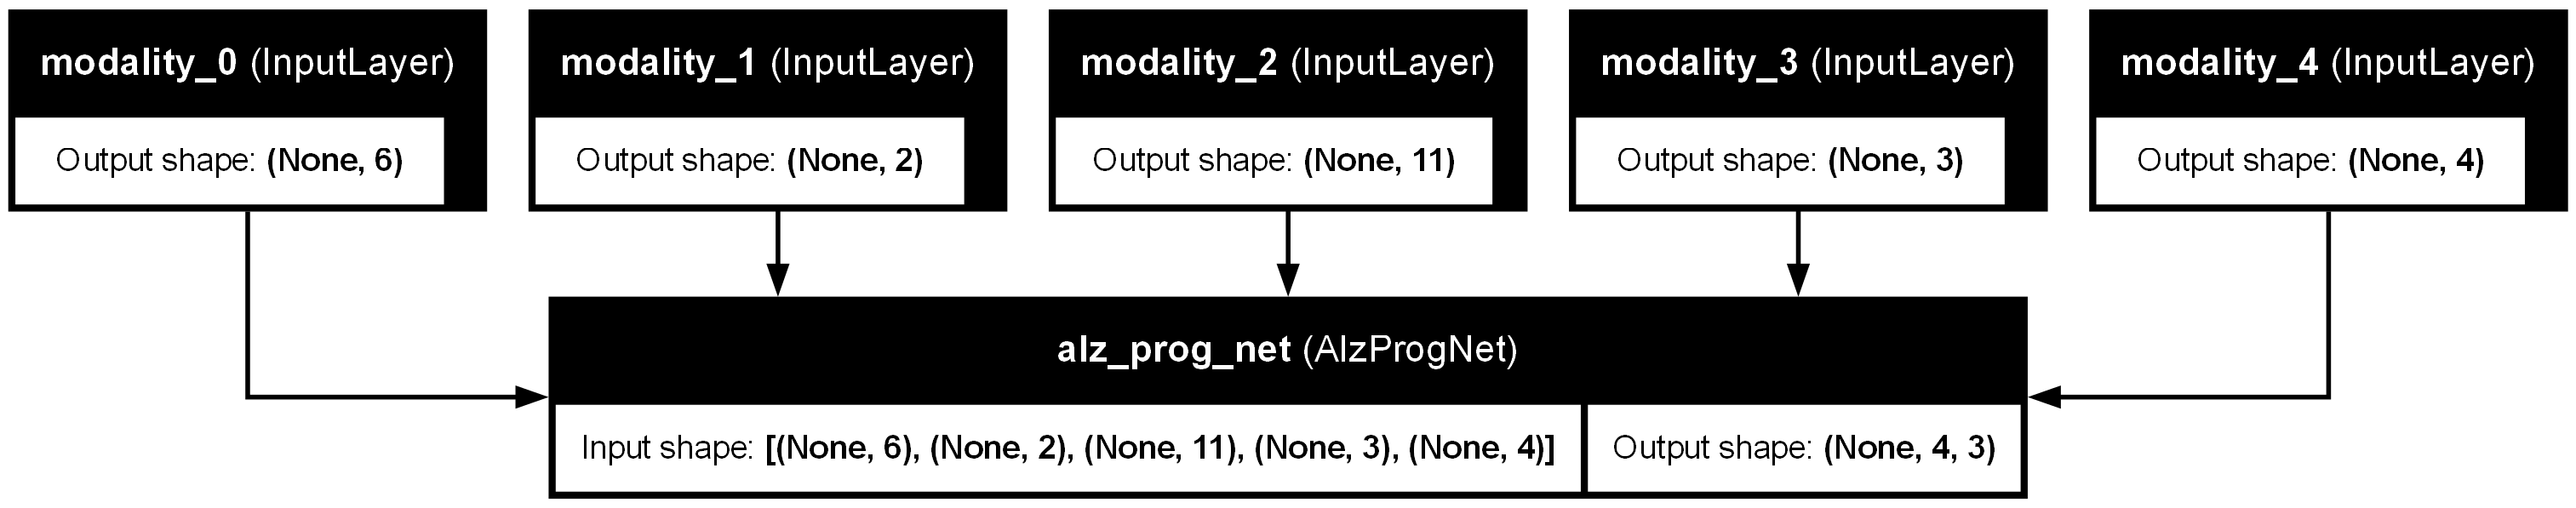

In [10]:
from keras.utils import plot_model

# Save the model architecture as a PNG file
plot_model(alz_prog_net, to_file='alz_prog_net_summary.png', show_shapes=True, show_layer_names=True, expand_nested=True)

In [11]:
# Define modality → column mapping
modality_slices = {
    "mri": slice(None, 6),
    "pet": slice(6, 8),
    "cog": slice(8, 19),
    "csf": slice(19, 22),
    "rf":  slice(22, 26),
}

# Build feature lists based on what's in `modalities`
def split_modalities(X, modalities):
    return [X[:, modality_slices[m]] for m in modalities if m in modality_slices]

In [12]:
pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", MinMaxScaler()),
])

combo = ("mri", "pet", "cog", "csf", "rf")

X_train_scaled = pipe.fit_transform(X_train)
X_val_scaled   = pipe.transform(X_val)
X_test_scaled  = pipe.transform(X_test)

X_train = split_modalities(X_train_scaled, combo)
X_val   = split_modalities(X_val_scaled, combo)
X_test  = split_modalities(X_test_scaled, combo)


In [13]:
import tensorflow as tf
from keras.losses import CategoricalCrossentropy


def longitudinal_categorical_crossentropy(
    weighted=False,
    time_weights=None,
    severity_weights=None
):
    """
    Longitudinal categorical cross-entropy.

    y_true shape:
        (N, 4, 3)

    y_pred shape:
        (N, 4, 3)

    Classes:
        0 = CN
        1 = MCI
        2 = AD

    time_weights:
        Weight for each time point.
        Example:
            [2.0, 1.5, 1.0, 0.5]

    severity_weights:
        3x3 matrix where:
            rows    = true class
            columns = predicted class

        Example:
            [[1.0, 2.0, 4.0],
             [2.0, 1.0, 3.0],
             [4.0, 2.0, 1.0]]
    """

    cce = CategoricalCrossentropy(
        from_logits=False,
        reduction=tf.keras.losses.Reduction.NONE
    )

    # ------------------------------------------------------
    # Time-point weights
    # ------------------------------------------------------

    if time_weights is None:
        time_weights = [1.0, 1.0, 1.0, 1.0]

    time_weights = tf.constant(
        time_weights,
        dtype=tf.float32
    )

    # ------------------------------------------------------
    # Severity matrix
    #
    #       predicted
    #          CN   MCI   AD
    #
    # true CN   1    2     4
    #      MCI  2    1     3
    #      AD   4    2     1
    # ------------------------------------------------------

    if severity_weights is None:
        severity_weights = [
            [1.0, 2.0, 4.0],
            [2.0, 1.0, 3.0],
            [4.0, 2.0, 1.0]
        ]

    severity_weights = tf.constant(
        severity_weights,
        dtype=tf.float32
    )

    def loss_fn(y_true, y_pred):

        # ==================================================
        # 1. Standard categorical cross entropy
        # ==================================================

        # Shape: (N, 4)
        group_losses = cce(
            y_true,
            y_pred
        )

        # ==================================================
        # 2. Determine true and predicted classes
        # ==================================================

        # Shape: (N, 4)
        true_class = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        predicted_class = tf.argmax(
            y_pred,
            axis=-1,
            output_type=tf.int32
        )

        # ==================================================
        # 3. Severity weighting
        # ==================================================

        # Flatten indices so we can gather from 3x3 matrix
        #
        # true_class:
        #     0, 1, 2
        #
        # predicted_class:
        #     0, 1, 2
        #
        # Result: (N, 4)

        indices = tf.stack(
            [
                true_class,
                predicted_class
            ],
            axis=-1
        )

        severity = tf.gather_nd(
            severity_weights,
            indices
        )

        # ==================================================
        # 4. Apply severity weighting
        # ==================================================

        severity_losses = (
            group_losses * severity
        )

        # ==================================================
        # 5. Apply time-point weighting
        # ==================================================

        weighted_losses = (
            severity_losses * time_weights
        )

        # Normalize so changing weights does not wildly
        # change the overall scale of the loss.

        weighted_losses = (
            weighted_losses
            * 4.0
            / tf.reduce_sum(time_weights)
        )

        # ==================================================
        # 6. Mean loss for each patient
        # ==================================================

        mean_loss_per_sample = tf.reduce_mean(
            weighted_losses,
            axis=-1
        )

        # ==================================================
        # 7. Optional stable/converter weighting
        # ==================================================

        if not weighted:
            return tf.reduce_mean(
                mean_loss_per_sample
            )

        first_col = true_class[:, 0:1]

        is_stable = tf.reduce_all(
            tf.equal(
                true_class,
                first_col
            ),
            axis=-1
        )

        is_stable = tf.cast(
            is_stable,
            tf.float32
        )

        is_converter = 1.0 - is_stable

        stable_count = tf.reduce_sum(
            is_stable
        )

        converter_count = tf.reduce_sum(
            is_converter
        )

        stable_loss = tf.math.divide_no_nan(
            tf.reduce_sum(
                mean_loss_per_sample * is_stable
            ),
            stable_count
        )

        converter_loss = tf.math.divide_no_nan(
            tf.reduce_sum(
                mean_loss_per_sample * is_converter
            ),
            converter_count
        )

        has_stable = stable_count > 0
        has_converter = converter_count > 0

        final_loss = tf.cond(
            tf.logical_and(
                has_stable,
                has_converter
            ),
            lambda: (
                stable_loss + converter_loss
            ) / 2.0,
            lambda: tf.reduce_mean(
                mean_loss_per_sample
            )
        )

        return final_loss

    loss_fn.__name__ = (
        "longitudinal_categorical_crossentropy_weighted"
        if weighted
        else "longitudinal_categorical_crossentropy"
    )

    return loss_fn


In [ ]:
import tensorflow as tf


def progression_aware_categorical_crossentropy(
    weighted=True,
    time_weights=None,
    severity_weights=None,
    progression_weight=1.0,
    stable_prediction_weight=1.0
):
    """
    Fully differentiable progression-aware longitudinal loss.

    ----------------------------------------------------------
    INPUT
    ----------------------------------------------------------

    y_true:
        Shape: (N, 4, 3)

    y_pred:
        Shape: (N, 4, 3)

    Classes:
        0 = CN
        1 = MCI
        2 = AD

    Time points:
        0 = current
        1 = 6 months
        2 = 12 months
        3 = 24 months

    ----------------------------------------------------------
    PARAMETERS
    ----------------------------------------------------------

    weighted:
        If True, stable and unstable patients are given equal
        importance in the final loss.

    time_weights:
        Relative importance of each time point.

    severity_weights:
        3x3 matrix:

                    PREDICTED
                  CN   MCI   AD

        TRUE CN   1    1.5   3
        TRUE MCI  1.5  1     2
        TRUE AD   3    2     1

    progression_weight:
        Weight of the progression under-estimation penalty.

    stable_prediction_weight:
        Weight of the penalty for predicting a progressing
        patient at or below their previous disease state.
    """

    # ======================================================
    # 1. TIME WEIGHTS
    # ======================================================

    if time_weights is None:
        time_weights = [
            0.75,   # current
            1.00,   # 6 months
            1.50,   # 12 months
            1.25    # 24 months
        ]

    time_weights = tf.constant(
        time_weights,
        dtype=tf.float32
    )

    # ======================================================
    # 2. SEVERITY WEIGHTS
    # ======================================================

    if severity_weights is None:
        severity_weights = [
            [1.0, 1.5, 3.0],
            [1.5, 1.0, 2.0],
            [3.0, 2.0, 1.0]
        ]

    severity_weights = tf.constant(
        severity_weights,
        dtype=tf.float32
    )

    # Disease-state values.
    #
    # CN  = 0
    # MCI = 1
    # AD  = 2

    class_values = tf.constant(
        [0.0, 1.0, 2.0],
        dtype=tf.float32
    )

    # ======================================================
    # LOSS FUNCTION
    # ======================================================

    def loss_fn(y_true, y_pred):

        # --------------------------------------------------
        # Ensure float32
        # --------------------------------------------------

        y_true = tf.cast(
            y_true,
            tf.float32
        )

        y_pred = tf.cast(
            y_pred,
            tf.float32
        )

        # --------------------------------------------------
        # Numerical stability
        # --------------------------------------------------

        y_pred = tf.clip_by_value(
            y_pred,
            1e-7,
            1.0 - 1e-7
        )

        # ==================================================
        # 3. TRUE CLASS
        # ==================================================

        # Shape:
        #
        # (N, 4)

        true_class = tf.argmax(
            y_true,
            axis=-1,
            output_type=tf.int32
        )

        # ==================================================
        # 4. STANDARD CATEGORICAL CROSS ENTROPY
        # ==================================================

        # Shape:
        #
        # (N, 4)

        cce = -tf.reduce_sum(
            y_true * tf.math.log(y_pred),
            axis=-1
        )

        # ==================================================
        # 5. DIFFERENTIABLE SEVERITY PENALTY
        # ==================================================
        #
        # IMPORTANT:
        #
        # There is NO argmax(y_pred) here.
        #
        # We use the entire probability distribution.
        #
        # --------------------------------------------------
        #
        # For true CN:
        #
        #   P(CN)  * 1
        # + P(MCI) * 1.5
        # + P(AD)  * 3
        #
        # --------------------------------------------------

        # Correctly gather one severity row for each
        # sample/time point.
        #
        # severity_weights:
        #     (3, 3)
        #
        # true_class:
        #     (N, 4)
        #
        # result:
        #     (N, 4, 3)

        true_severity_weights = tf.gather(
            severity_weights,
            true_class
        )

        # Expected severity under predicted distribution.
        #
        # Shape:
        #     (N, 4)

        expected_severity = tf.reduce_sum(
            y_pred * true_severity_weights,
            axis=-1
        )

        # --------------------------------------------------
        # Correct-class severity baseline
        # --------------------------------------------------
        #
        # For each true class, get:
        #
        # CN  -> severity_weights[CN, CN]
        # MCI -> severity_weights[MCI, MCI]
        # AD  -> severity_weights[AD, AD]
        #
        # Normally these are all 1.0.
        #
        # This makes the penalty relative to the correct
        # classification rather than simply using 1.0.

        correct_class_weights = tf.gather(
            tf.linalg.diag_part(severity_weights),
            true_class
        )

        severity_penalty = tf.maximum(
            expected_severity
            - correct_class_weights,
            0.0
        )

        # ==================================================
        # 6. PROGRESSION UNDER-PREDICTION
        # ==================================================
        #
        # We explicitly penalize:
        #
        # True future state > predicted expected state
        #
        # Example:
        #
        # True:
        #     CN -> MCI
        #
        # Prediction:
        #     CN = 0.80
        #     MCI = 0.15
        #     AD = 0.05
        #
        # Expected state:
        #
        #     0.80*0 + 0.15*1 + 0.05*2
        #     = 0.25
        #
        # True state = 1
        #
        # Under-prediction = 1 - 0.25 = 0.75
        # ==================================================

        progression_penalties = []

        for t in range(1, 4):

            true_future_state = tf.cast(
                true_class[:, t],
                tf.float32
            )

            true_previous_state = tf.cast(
                true_class[:, t - 1],
                tf.float32
            )

            # Amount of actual progression.
            #
            # CN -> MCI = 1
            # CN -> AD  = 2
            # MCI -> AD = 1
            # Stable    = 0

            true_progression = tf.maximum(
                true_future_state
                - true_previous_state,
                0.0
            )

            # Expected disease state from softmax.

            expected_predicted_state = tf.reduce_sum(
                y_pred[:, t, :]
                * class_values,
                axis=-1
            )

            # How much the model underestimates the true
            # future state.

            under_prediction = tf.maximum(
                true_future_state
                - expected_predicted_state,
                0.0
            )

            # Only penalize actual progression.

            progression_penalty = (
                true_progression
                * under_prediction
            )

            progression_penalties.append(
                progression_penalty
            )

        # Shape:
        #
        # (N, 3)

        progression_penalties = tf.stack(
            progression_penalties,
            axis=-1
        )

        # Give future time points their corresponding weights.

        progression_penalties = (
            progression_penalties
            * time_weights[1:]
        )

        # Shape:
        #
        # (N,)

        progression_penalty = tf.reduce_mean(
            progression_penalties,
            axis=-1
        )

        # ==================================================
        # 7. PENALIZE PREDICTING "NO PROGRESSION"
        # ==================================================
        #
        # This specifically targets:
        #
        # True:
        #     CN -> MCI
        #
        # Model:
        #     CN = 0.90
        #     MCI = 0.08
        #     AD = 0.02
        #
        # We calculate the probability of predicting a
        # state at or below the previous true state.
        # ==================================================

        stable_prediction_penalties = []

        for t in range(1, 4):

            previous_true_state = true_class[:, t - 1]

            current_true_state = true_class[:, t]

            # Is this patient actually progressing?

            true_progressing = tf.cast(
                current_true_state > previous_true_state,
                tf.float32
            )

            # Cumulative probabilities:
            #
            # CN:
            #     [P(CN)]
            #
            # MCI:
            #     [P(CN), P(CN)+P(MCI)]
            #
            # AD:
            #     [P(CN), P(CN)+P(MCI), 1]

            cumulative_probabilities = tf.cumsum(
                y_pred[:, t, :],
                axis=-1
            )

            # Select cumulative probability corresponding
            # to the previous disease state.

            previous_state_mask = tf.one_hot(
                previous_true_state,
                depth=3,
                dtype=tf.float32
            )

            probability_at_or_below_previous = tf.reduce_sum(
                cumulative_probabilities
                * previous_state_mask,
                axis=-1
            )

            # Only penalize actual progressors.

            penalty = (
                true_progressing
                * probability_at_or_below_previous
            )

            stable_prediction_penalties.append(
                penalty
            )

        # Shape:
        #
        # (N, 3)

        stable_prediction_penalties = tf.stack(
            stable_prediction_penalties,
            axis=-1
        )

        stable_prediction_penalties = (
            stable_prediction_penalties
            * time_weights[1:]
        )

        # Shape:
        #
        # (N,)

        stable_prediction_penalty = tf.reduce_mean(
            stable_prediction_penalties,
            axis=-1
        )

        # ==================================================
        # 8. COMBINE LOSS COMPONENTS
        # ==================================================

        total_group_loss = (
            cce
            + severity_penalty
            + progression_weight
            * progression_penalty
            + stable_prediction_weight
            * stable_prediction_penalty
        )

        # ==================================================
        # 9. TIME WEIGHTING
        # ==================================================

        total_group_loss = (
            total_group_loss
            * time_weights
        )

        # Normalize time weighting so changing the weights
        # doesn't drastically change the overall loss scale.

        total_group_loss = (
            total_group_loss
            * 4.0
            / tf.reduce_sum(time_weights)
        )

        # ==================================================
        # 10. MEAN OVER FOUR TIME POINTS
        # ==================================================

        mean_loss_per_sample = tf.reduce_mean(
            total_group_loss,
            axis=-1
        )

        # ==================================================
        # 11. STABLE / UNSTABLE BALANCING
        # ==================================================

        if not weighted:
            return tf.reduce_mean(
                mean_loss_per_sample
            )

        # Stable if all four time points have the same
        # disease class.

        first_class = true_class[:, 0:1]

        is_stable = tf.reduce_all(
            tf.equal(
                true_class,
                first_class
            ),
            axis=-1
        )

        is_stable = tf.cast(
            is_stable,
            tf.float32
        )

        is_unstable = 1.0 - is_stable

        stable_count = tf.reduce_sum(
            is_stable
        )

        unstable_count = tf.reduce_sum(
            is_unstable
        )

        # --------------------------------------------------
        # Stable loss
        # --------------------------------------------------

        stable_loss = tf.math.divide_no_nan(
            tf.reduce_sum(
                mean_loss_per_sample
                * is_stable
            ),
            stable_count
        )

        # --------------------------------------------------
        # Unstable loss
        # --------------------------------------------------

        unstable_loss = tf.math.divide_no_nan(
            tf.reduce_sum(
                mean_loss_per_sample
                * is_unstable
            ),
            unstable_count
        )

        has_stable = stable_count > 0
        has_unstable = unstable_count > 0

        # Equal contribution from stable and unstable groups.

        final_loss = tf.cond(
            tf.logical_and(
                has_stable,
                has_unstable
            ),
            lambda: (
                stable_loss
                + unstable_loss
            ) / 2.0,
            lambda: tf.reduce_mean(
                mean_loss_per_sample
            )
        )

        return final_loss

    loss_fn.__name__ = (
        "progression_aware_categorical_crossentropy"
    )

    return loss_fn


In [15]:
import tensorflow as tf


def grouped_categorical_accuracy(y_true, y_pred):
    """
    Computes average categorical accuracy for 4 grouped outputs.

    y_true: (N, 4, 3)
    y_pred: (N, 4, 3)

    Last dimension:
        0 = CN
        1 = MCI
        2 = AD

    Returns:
        Scalar accuracy averaged across samples and 4 groups.
    """

    # Convert one-hot labels to class indices
    # Shape: (N, 4)
    true_labels = tf.argmax(
        y_true,
        axis=-1
    )

    # Convert softmax predictions to predicted class
    # Shape: (N, 4)
    pred_labels = tf.argmax(
        y_pred,
        axis=-1
    )

    # Correct/incorrect for each group
    # Shape: (N, 4)
    correct = tf.cast(
        tf.equal(true_labels, pred_labels),
        tf.float32
    )

    # Average across the 4 time points
    # Shape: (N,)
    mean_accuracy = tf.reduce_mean(
        correct,
        axis=-1
    )

    # Average across batch
    return tf.reduce_mean(mean_accuracy)


In [16]:
time_weights = [
    0.75,   # current
    1.00,   # 6 months
    1.50,   # 12 months
    1.25    # 24 months
]

 # Severity matrix
#
#       predicted
#          CN   MCI   AD
#
# true CN   1    X     2
#      MCI  X    1     X
#      AD   2    X     1
severity_weights=[
    [1.0, 1.5, 3.0],   # true CN
    [1.5, 1.0, 2.0],   # true MCI
    [3.0, 2.0, 1.0]    # true AD
],

In [17]:


optimizer = keras.optimizers.AdamW()
# loss = longitudinal_categorical_crossentropy(
#     weighted=True,

#     time_weights=time_weights,

#     severity_weights=severity_weights
# )

loss = progression_aware_categorical_crossentropy(
    weighted=True,
    time_weights=time_weights,
    severity_weights=severity_weights,
    progression_weight=1.0,
    stable_prediction_weight=1.0
)

alz_prog_net.compile(
    optimizer=optimizer,
    loss = loss,
    metrics = [grouped_categorical_accuracy]
)

kfold_dir = f"models"
os.makedirs(kfold_dir, exist_ok=True)
model_path = os.path.join(kfold_dir, f'best_model.keras')

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=50, 
        restore_best_weights=True, 
        verbose=0
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.9, 
        patience=10, 
        min_lr=1e-6, 
        verbose=0
    ),
    keras.callbacks.ModelCheckpoint(
        model_path, 
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

history = alz_prog_net.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

InvalidArgumentError: {{function_node __wrapped__EnsureShape_device_/job:localhost/replica:0/task:0/device:CPU:0}} Shape of tensor input [1,3,3] is not compatible with expected shape [3,3]. [Op:EnsureShape] name: 

In [ ]:
import numpy as np
import tensorflow as tf


def evaluate_model(
    y_true,
    y_pred,
    time_weights=None,
    severity_weights=None
):
    """
    Evaluate longitudinal model predictions.

    Parameters
    ----------
    y_true : array-like
        Shape: (N, 4, 3)
        One-hot encoded true labels.

    y_pred : array-like
        Shape: (N, 4, 3)
        Softmax predictions.

    time_weights : array-like, optional
        Weight for each time point.
        Example:
            [2.0, 1.5, 1.0, 0.75]

    severity_weights : array-like, optional
        3x3 matrix:
            rows    = true class
            columns = predicted class

        Example:
            [[1.0, 1.5, 3.0],
             [1.5, 1.0, 2.0],
             [3.0, 2.0, 1.0]]

    Returns
    -------
    dict
        Results for stable, unstable, and total samples.
    """

    # ------------------------------------------------------
    # Convert to tensors
    # ------------------------------------------------------

    y_true = tf.convert_to_tensor(
        y_true,
        dtype=tf.float32
    )

    y_pred = tf.convert_to_tensor(
        y_pred,
        dtype=tf.float32
    )

    # ------------------------------------------------------
    # Validate shape
    # ------------------------------------------------------

    if len(y_true.shape) != 3:
        raise ValueError(
            f"y_true must have shape (N, 4, 3), "
            f"got {y_true.shape}"
        )

    if len(y_pred.shape) != 3:
        raise ValueError(
            f"y_pred must have shape (N, 4, 3), "
            f"got {y_pred.shape}"
        )

    if y_true.shape[1:] != (4, 3):
        raise ValueError(
            f"y_true must have shape (N, 4, 3), "
            f"got {y_true.shape}"
        )

    if y_pred.shape[1:] != (4, 3):
        raise ValueError(
            f"y_pred must have shape (N, 4, 3), "
            f"got {y_pred.shape}"
        )

    # ------------------------------------------------------
    # Default weights
    # ------------------------------------------------------

    if time_weights is None:
        time_weights = [
            1.0, 1.0, 1.0, 1.0
        ]

    if severity_weights is None:
        severity_weights = [
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0],
            [1.0, 1.0, 1.0]
        ]

    time_weights = tf.constant(
        time_weights,
        dtype=tf.float32
    )

    severity_weights = tf.constant(
        severity_weights,
        dtype=tf.float32
    )

    # ------------------------------------------------------
    # Class labels
    #
    # Shape: (N, 4)
    #
    # 0 = CN
    # 1 = MCI
    # 2 = AD
    # ------------------------------------------------------

    true_labels = tf.argmax(
        y_true,
        axis=-1,
        output_type=tf.int32
    )

    pred_labels = tf.argmax(
        y_pred,
        axis=-1,
        output_type=tf.int32
    )

    # ------------------------------------------------------
    # Stable / unstable
    #
    # Stable:
    # all 4 time points have the same diagnosis.
    #
    # Unstable:
    # at least one time point differs.
    # ------------------------------------------------------

    first_label = true_labels[:, 0:1]

    stable_mask = tf.reduce_all(
        tf.equal(
            true_labels,
            first_label
        ),
        axis=-1
    )

    unstable_mask = tf.logical_not(
        stable_mask
    )

    # ------------------------------------------------------
    # Per-group accuracy
    # ------------------------------------------------------

    accuracy_per_group = tf.cast(
        tf.equal(
            true_labels,
            pred_labels
        ),
        tf.float32
    )
    # Shape: (N, 4)

    # ------------------------------------------------------
    # Categorical cross entropy
    # ------------------------------------------------------

    # Avoid log(0)
    y_pred_clipped = tf.clip_by_value(
        y_pred,
        1e-7,
        1.0
    )

    # CCE manually over class dimension
    #
    # Shape: (N, 4)
    group_losses = -tf.reduce_sum(
        y_true * tf.math.log(y_pred_clipped),
        axis=-1
    )

    # ------------------------------------------------------
    # Severity weighting
    # ------------------------------------------------------

    indices = tf.stack(
        [
            true_labels,
            pred_labels
        ],
        axis=-1
    )

    severity = tf.gather_nd(
        severity_weights,
        indices
    )
    # Shape: (N, 4)

    severity_losses = (
        group_losses * severity
    )

    # ------------------------------------------------------
    # Time weighting
    # ------------------------------------------------------

    weighted_losses = (
        severity_losses * time_weights
    )

    # Normalize time weights
    weighted_losses = (
        weighted_losses
        * 4.0
        / tf.reduce_sum(time_weights)
    )

    # ------------------------------------------------------
    # Per-sample metrics
    # ------------------------------------------------------

    mean_accuracy_per_sample = tf.reduce_mean(
        accuracy_per_group,
        axis=-1
    )

    mean_loss_per_sample = tf.reduce_mean(
        weighted_losses,
        axis=-1
    )

    # ------------------------------------------------------
    # Helper
    # ------------------------------------------------------

    def safe_mean(values):

        if tf.size(values).numpy() == 0:
            return np.nan

        return float(
            tf.reduce_mean(values).numpy()
        )

    # ------------------------------------------------------
    # Evaluate stable / unstable group
    # ------------------------------------------------------

    def compute_for_mask(mask):

        results = {}

        # Number of samples
        count = int(
            tf.reduce_sum(
                tf.cast(mask, tf.int32)
            ).numpy()
        )

        # ----------------------------------------------
        # Each time point
        # ----------------------------------------------

        time_names = [
            "current",
            "6_month",
            "12_month",
            "24_month"
        ]

        for i, time_name in enumerate(time_names):

            masked_acc = tf.boolean_mask(
                accuracy_per_group[:, i],
                mask
            )

            masked_loss = tf.boolean_mask(
                weighted_losses[:, i],
                mask
            )

            results[time_name] = {
                "accuracy": safe_mean(
                    masked_acc
                ),
                "loss": safe_mean(
                    masked_loss
                )
            }

        # ----------------------------------------------
        # Overall
        # ----------------------------------------------

        masked_accuracy = tf.boolean_mask(
            mean_accuracy_per_sample,
            mask
        )

        masked_loss = tf.boolean_mask(
            mean_loss_per_sample,
            mask
        )

        results["overall"] = {
            "accuracy": safe_mean(
                masked_accuracy
            ),
            "loss": safe_mean(
                masked_loss
            )
        }

        results["count"] = count

        return results

    # ------------------------------------------------------
    # Return
    # ------------------------------------------------------

    return {
        "stable": compute_for_mask(
            stable_mask
        ),

        "unstable": compute_for_mask(
            unstable_mask
        ),

        "total_count": int(
            y_true.shape[0]
        )
    }


In [ ]:
y_pred = alz_prog_net.predict(X_test)

results = evaluate_model(
    y_test,
    y_pred,
    time_weights=time_weights,
    severity_weights=severity_weights
)

results

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step


{'stable': {'current': {'accuracy': 0.790224015712738,
   'loss': 0.39219772815704346},
  '6_month': {'accuracy': 0.8655804395675659, 'loss': 0.38775932788848877},
  '12_month': {'accuracy': 0.9002036452293396, 'loss': 0.44708752632141113},
  '24_month': {'accuracy': 0.8146639466285706, 'loss': 0.5678760409355164},
  'overall': {'accuracy': 0.8426679968833923, 'loss': 0.4487301707267761},
  'count': 491},
 'unstable': {'current': {'accuracy': 0.8714285492897034,
   'loss': 0.36320286989212036},
  '6_month': {'accuracy': 0.7142857313156128, 'loss': 0.750060498714447},
  '12_month': {'accuracy': 0.6285714507102966, 'loss': 1.0521351099014282},
  '24_month': {'accuracy': 0.7857142686843872, 'loss': 0.577580451965332},
  'overall': {'accuracy': 0.75, 'loss': 0.6857448220252991},
  'count': 70},
 'total_count': 561}